In [1]:
from pathlib import Path
import os 
import sys
import torch
import torch.nn as nn
import numpy as np
import torch.nn.init as init
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.transforms import transforms
from torchinfo import summary
import json

In [2]:
ROOT_DIR = Path.cwd().parent
ROOT_DIR

WindowsPath('D:/Code Module 6/Excercise_Week_2_Module_6')

In [3]:
SRC_DIR = ROOT_DIR/'src'

In [4]:
TRAIN_DIR = ROOT_DIR/'data'/'scenes_classification'/'train'

In [5]:
MODEL_DIR = ROOT_DIR/'model_base'

In [6]:
# Thêm các folder vào không gian tìm kiếm của notebooks
sys.path.extend([str(SRC_DIR),str(MODEL_DIR),str(ROOT_DIR)])

In [7]:
from precessing_data import *
from ResNet_model import ResNet, ResNet18

# Set tham số seed để cố định các tham số khởi tạo ngẫu nhiên

In [8]:
# Khởi tạo seed để cố định bộ trọng số khởi tạo ngẫu nhiên
def set_seed(seed):
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)

In [9]:
seed = 42
set_seed(seed)

In [10]:
# dict mã hóa label -> index và từ index-> label
label2idx, idx2label = Code_decode_label(TRAIN_DIR)

In [11]:
label2idx

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [12]:
num_classes = len(label2idx)
num_classes

6

In [13]:
# Lấy đường dẫn ảnh và nhãn tương ứng
img_paths, labels = get_imgPath_label(TRAIN_DIR, label2idx=label2idx)

In [14]:
img_paths

['D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\0.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\10006.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\1001.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\10014.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\10018.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\10029.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\10032.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\10056.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Module_6\\data\\scenes_classification\\train\\buildings\\1009.jpg',
 'D:\\Code Module 6\\Excercise_Week_2_Modul

In [15]:
labels

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


# Lấy DL tập TrainDataSet và ValDataSet

In [16]:
train_dataset = ImageDataSet(img_paths=img_paths, labels=labels, val_split=0.1, train=True,random_state=seed)

In [17]:
print(f"the num sample in trainset: {len(train_dataset)}")

the num sample in trainset: 12630


In [18]:
train_dataset[0][0].shape

torch.Size([3, 150, 150])

In [19]:
val_dataset = ImageDataSet(img_paths=img_paths, labels=labels, val_split=0.1, train=False,random_state=seed)

In [20]:
print(f"the num sample in valset: {len(val_dataset)}")

the num sample in valset: 1404


# Thực hiện tiền xử lý ảnh trên tập với một số phép biến đổi resize, normalize, data augmentation 

Tiền xử lý trên tập train

In [21]:
# Resize lại  kích thước của ảnh
train_dataset = ImageDataSet(img_paths=img_paths, labels=labels, val_split=0.1, train=True,random_state=seed, transforms=[transforms.Resize((224,224)),])
train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [22]:
# Hàm tính mean std của dữ liệu train để chuẩn hóa DL ảnh đầu vào của mô hình
def compute_mean_std(dataset, batch_size = 1024, channel = 3):
    means = torch.zeros(channel)
    stds = torch.zeros(channel)
    dataloader = DataLoader(dataset, shuffle=True, batch_size=batch_size)
    num_samples = len(dataset)
    for img, _ in dataloader:
        size_batch = img.shape[0]
        img = img.view(batch_size,3,-1)
        means+= torch.mean(img, dim = (0,2))*size_batch
        stds += torch.std(img,dim = (0,2))*size_batch
    means/= num_samples
    stds/= num_samples
    return means, stds

In [23]:
mean, std = compute_mean_std(train_dataset)
print(mean)
print(std)

tensor([0.4306, 0.4573, 0.4538])
tensor([0.2603, 0.2590, 0.2901])


In [24]:
list_transforms = [transforms.Resize((224,224)),
                            transforms.Normalize(mean=mean, std= std),
                            transforms.RandomRotation(degrees=(-90,90)),
                            transforms.RandomErasing(p=0.2, scale=(0.01, 0.3), ratio=(0.1, 0.1), value=0, inplace=True),
                            transforms.RandomHorizontalFlip(p=0.2)]
train_dataset = ImageDataSet(img_paths=img_paths, labels=labels, val_split=0.1, train=True,random_state=seed, transforms=list_transforms)

Tiền xử lý trên tập val

In [25]:
val_dataset = ImageDataSet(img_paths=img_paths,
                           labels=labels,
                           val_split=0.1,
                           train=False,
                           random_state=seed,
                           transforms=[transforms.Resize((224, 224)), transforms.Normalize(mean=mean, std=std)])

In [26]:
val_dataset[0][0].shape

torch.Size([3, 224, 224])

In [27]:
classifier = ResNet(version=18, num_classes=6)

In [28]:
summary(classifier.model, input_size=(128,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [128, 6]                  --
├─Conv2d: 1-1                            [128, 64, 112, 112]       9,472
├─BatchNorm2d: 1-2                       [128, 64, 112, 112]       128
├─ReLU: 1-3                              [128, 64, 112, 112]       --
├─MaxPool2d: 1-4                         [128, 64, 56, 56]         --
├─ResidualBlock: 1-5                     [128, 64, 56, 56]         --
│    └─Sequential: 2-1                   [128, 64, 56, 56]         --
│    │    └─Conv2d: 3-1                  [128, 64, 56, 56]         36,928
│    │    └─BatchNorm2d: 3-2             [128, 64, 56, 56]         128
│    │    └─ReLU: 3-3                    [128, 64, 56, 56]         --
│    │    └─Conv2d: 3-4                  [128, 64, 56, 56]         36,928
│    │    └─BatchNorm2d: 3-5             [128, 64, 56, 56]         128
├─ReLU: 1-6                              [128, 64, 56, 56]         --
├

In [29]:
for layer in classifier.model:
    if isinstance(layer,nn.Linear) or isinstance(layer,nn.Conv2d):
        init.kaiming_normal_(layer.weight)
        init.zeros_(layer.bias)

In [30]:
optimizer = torch.optim.SGD(classifier.model.parameters(), lr=0.01, momentum=0.8,nesterov=True, weight_decay=0.0001)

In [31]:
classifier.fit(dataset=train_dataset, val_dataset=val_dataset, batch_size=128, n_epochs=100, verbose=2, is_shuffle=True,criterion='CE', optimizer=optimizer,random_state=seed)

  0%|                                                                                          | 0/100 [00:00<?, ?it/s]

Epoch [   1/100]


  1%|▊                                                                               | 1/100 [01:08<1:52:58, 68.47s/it]

Loss = 1.1020 - Accuracy = 0.5827 - Loss_Validation = 0.9789 - Accracy_Validation = 0.6439
Epoch [   2/100]


  2%|█▌                                                                              | 2/100 [02:14<1:49:32, 67.06s/it]

...

Loss = 0.0816 - Accuracy = 0.9691 - Loss_Validation = 0.5569 - Accracy_Validation = 0.8810
Epoch [  99/100]


 99%|██████████████████████████████████████████████████████████████████████████████▏| 99/100 [1:47:38<01:04, 64.71s/it]

Loss = 0.0764 - Accuracy = 0.9726 - Loss_Validation = 0.4927 - Accracy_Validation = 0.8910
Epoch [ 100/100]


100%|██████████████████████████████████████████████████████████████████████████████| 100/100 [1:48:43<00:00, 65.23s/it]

Loss = 0.0846 - Accuracy = 0.9716 - Loss_Validation = 0.5622 - Accracy_Validation = 0.8739


In [32]:
# Lưu trọng số huấn luyện
torch.save(classifier.model.state_dict(),ROOT_DIR/'model_weight.pth')

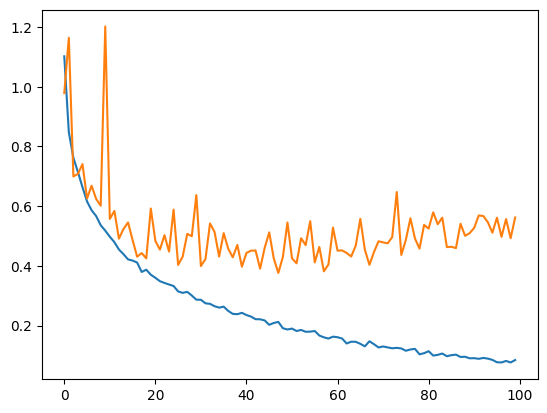

In [33]:
plt.plot(classifier.Losses)
plt.plot(classifier.Val_Losses)

In [34]:
classifier1 = ResNet(version=18, num_classes=6)

In [35]:
summary(classifier1.model, input_size=(1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 6]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,472
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─ResidualBlock: 1-5                     [1, 64, 56, 56]           --
│    └─Sequential: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,928
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,928
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
├─ReLU: 1-6                              [1, 64, 56, 56]           --
├